In [1]:
import cv2 as cv
import numpy as np
import os
import matplotlib.pyplot as plt


In [3]:
sample_img_name = "image_512.jpg"
folder = "data/image_folder"

img_path = os.path.join(folder, sample_img_name)
img = cv.imread(img_path)

In [4]:
print(img_path)

data/image_folder/image_512.jpg


In [5]:
print(img.shape)

(360, 640, 3)


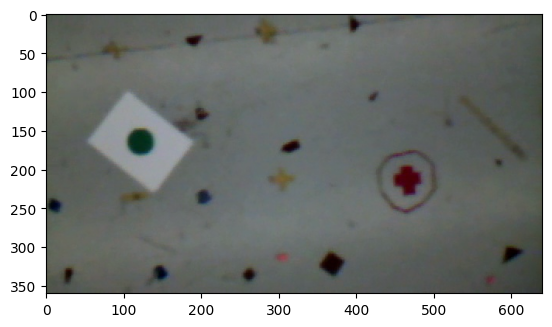

In [6]:
plt.imshow(img)

In [7]:
img_gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

In [8]:
print(img_gray.shape)

(360, 640)


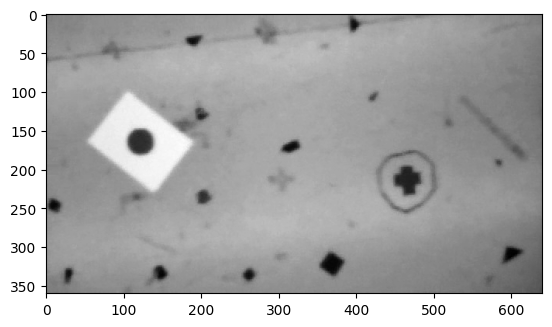

In [9]:
plt.imshow(img_gray, cmap='gray')

In [10]:
blurred = cv.GaussianBlur(img_gray, (3, 3), 0)
filtered_LoG = cv.Laplacian(blurred, cv.CV_16S, ksize=3)

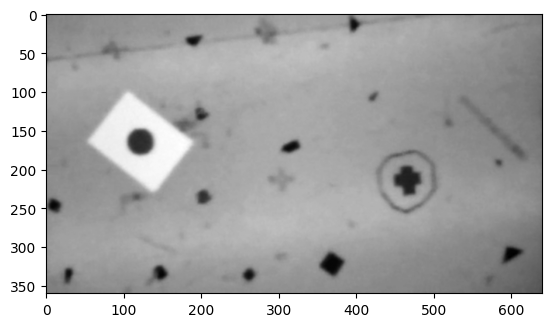

In [11]:
plt.imshow(blurred, cmap='gray')

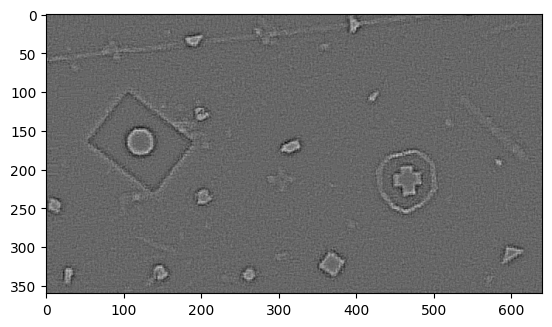

In [12]:
plt.imshow(filtered_LoG, cmap='gray')

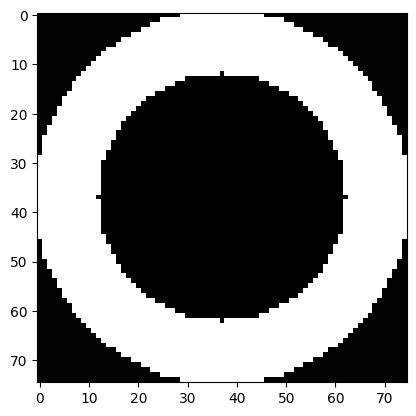

In [13]:
blank = np.ones((75,75), np.float64)
# cv.circle(	img, center, radius, color[, thickness[, lineType[, shift]]]	) -> 	img
circle_template_0 = cv.circle(blank,(37,37),np.round(75/2).astype(np.uint8) , 255, -1)
circle_template = cv.circle(circle_template_0,(37,37),25 , 0, -1)
plt.imshow(circle_template, cmap='gray')

In [14]:
#dst = cv.filter2D(src, ddepth, kernel, anchor=(-1, -1), delta=0, borderType=cv.BORDER_DEFAULT)
blurred_float = blurred/255.0
test_filtered_img = cv.filter2D(blurred_float, -1, circle_template, borderType=cv.BORDER_DEFAULT)

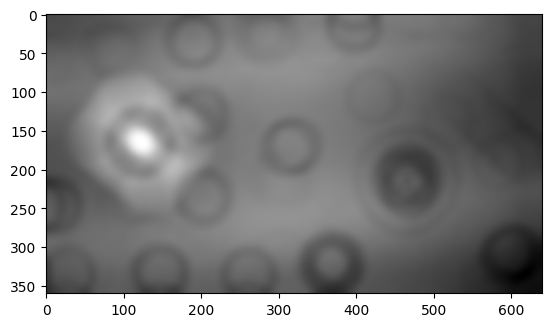

In [15]:
filtered_max = np.max(test_filtered_img.flatten())
filtered_min = np.min(test_filtered_img.flatten())
img_range = filtered_max - filtered_min
test_filtered_img = (test_filtered_img - filtered_min)/img_range
plt.imshow(test_filtered_img, cmap='gray')


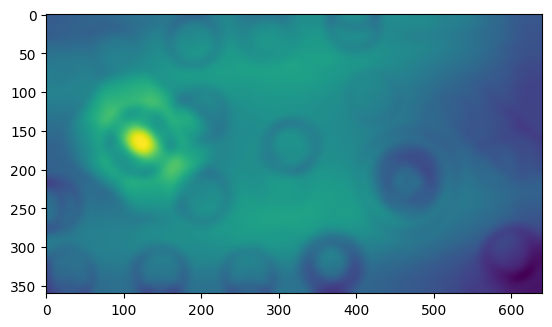

In [16]:
plt.imshow(test_filtered_img)

ret= 200.0


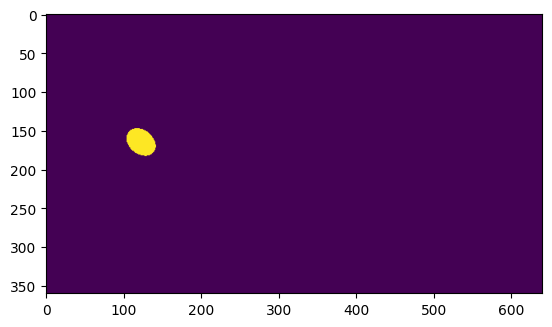

In [17]:
ret,filtered_thresholded = cv.threshold((test_filtered_img*255).astype(np.uint8),200,255,cv.THRESH_BINARY)
plt.imshow(filtered_thresholded)
print("ret=",ret)

In [18]:
np.max(blurred.flatten())

np.uint8(164)

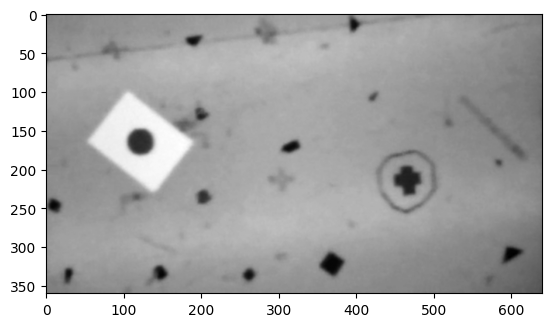

In [19]:
plt.imshow(blurred, cmap='gray')

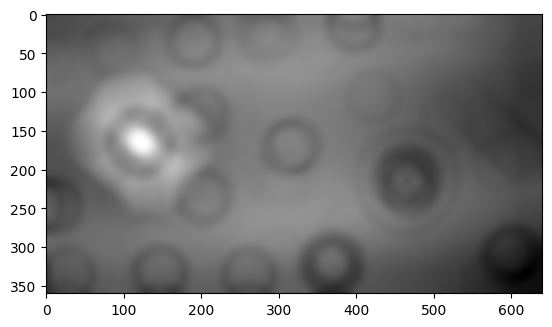

In [20]:
test_filtered_img_no_blur = cv.filter2D(img_gray/255.0, -1, circle_template, borderType=cv.BORDER_DEFAULT)
plt.imshow(test_filtered_img_no_blur, cmap='gray')

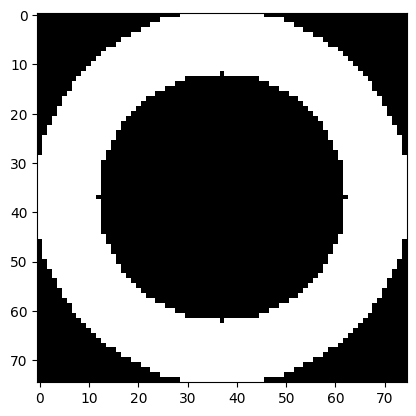

In [23]:
blank_new = np.zeros((75,75), np.uint8)
circle_template_0 = cv.circle(blank_new,(37,37),np.round(75/2).astype(np.uint8) , 255, -1)
circle_template = cv.circle(circle_template_0,(37,37),25 , 0, -1)
plt.imshow(circle_template, cmap='gray')


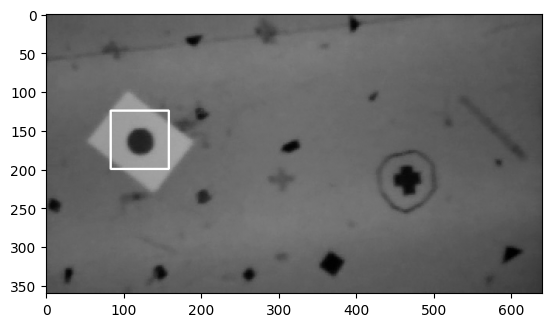

In [24]:
img_new = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

res = cv.matchTemplate(img_new,circle_template,cv.TM_CCOEFF)
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
top_left = max_loc
(w,h) = circle_template.shape
bottom_right = (top_left[0] + w, top_left[1] + h)
cv.rectangle(img_new,top_left, bottom_right, 255, 2)
plt.imshow(img_new, cmap='gray')

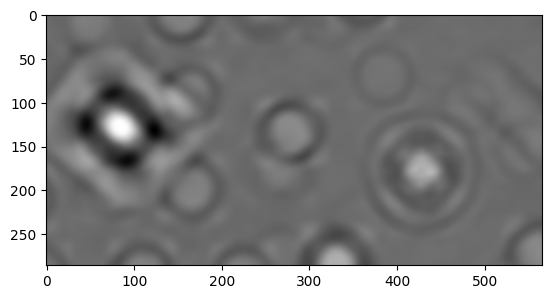

In [25]:
plt.imshow(res, cmap='gray')

In [53]:
# Ideas
# [DONE] Try template matching
# [DONE] try improving filter - outside all zeros, then one ring of ones, then inner ring of zeros
# [SKIP] after convolutional filter, try blob detection using Laplacian of Gaussians

# TODO
# [DONE] find image with different scale
# idea - after finding first guess, optimize the following black circle radius, center
# [] find image with multiple circles; test on this
# [] get multi-circle detection working
# [] try multi-scale

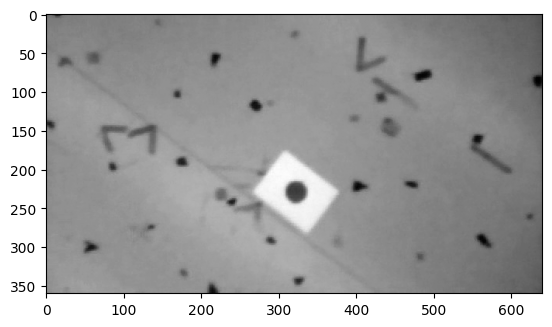

In [42]:
# different scale image - 2696
# multiple targets - 844 (partial obscured) 879 - 882img_new = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
img_2696 = cv.imread(os.path.join(folder, "image_2696.jpg"), cv.IMREAD_GRAYSCALE)
plt.imshow(img_2696, cmap='gray')

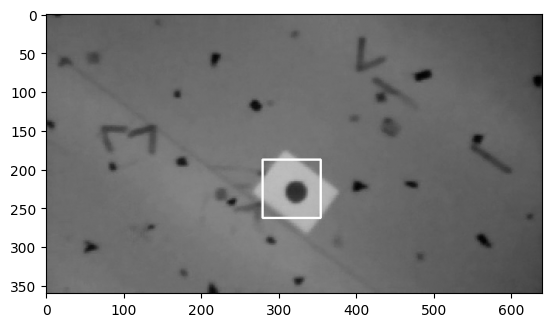

In [43]:
res = cv.matchTemplate(img_2696,circle_template,cv.TM_CCOEFF)
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
top_left = max_loc
(w,h) = circle_template.shape
bottom_right = (top_left[0] + w, top_left[1] + h)
cv.rectangle(img_2696,top_left, bottom_right, 255, 2)
plt.imshow(img_2696, cmap='gray')

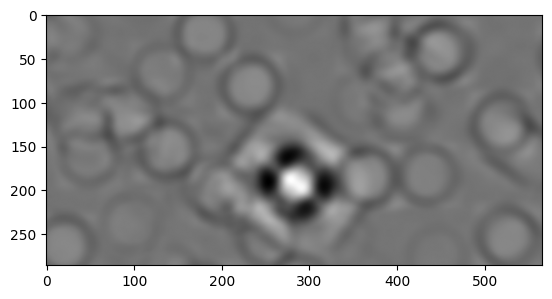

In [44]:
plt.imshow(res, cmap='gray')

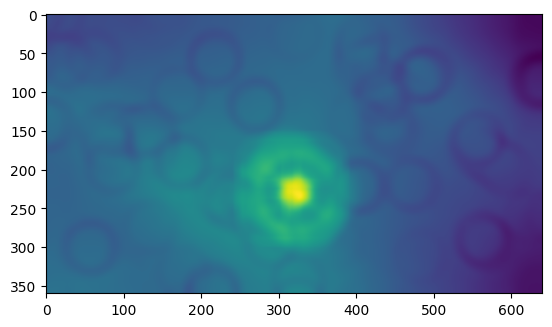

In [45]:
img2696_convolved = cv.filter2D(img_2696/255.0, -1, circle_template, borderType=cv.BORDER_DEFAULT)
plt.imshow(img2696_convolved)

In [46]:
max_pixel_idx = np.unravel_index(img2696_convolved.argmax(), img2696_convolved.shape)
max_pixel_idx

(np.int64(234), np.int64(327))

In [74]:
np.min(filtered_LoG)

np.int16(-300)

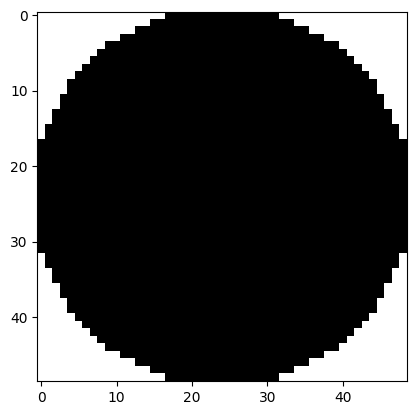

In [87]:
blank_new = np.ones((49,49), np.uint8)
circle_template = cv.circle(blank_new,(24,24),25, 0, -1)
plt.imshow(circle_template, cmap='gray')

In [134]:
img_2696 = cv.imread(os.path.join(folder, "image_2696.jpg"), cv.IMREAD_GRAYSCALE)
current_img = img_2696

print(current_img.shape)

initial_y = max_pixel_idx[0]
initial_x = max_pixel_idx[1]

initial_radius = 24

min_radius = 14
max_radius = 34
min_x = initial_x - 20
max_x = initial_x + 20 + 1

min_y = initial_y - 20
max_y = initial_y + 20 + 1

min_error = np.inf
best_parameters = (0,0,0)

for x in range(min_x, max_x):
    for y in range(min_y, max_y):
        for r in range(min_radius, max_radius):
            w = r * 2 + 1
            if x <= 0:
                continue
            if x >= current_img.shape[1] - w:
                continue
            if y <= 0:
                continue
            if y >= current_img.shape[0] - w:
                continue
            blank_new = np.ones((w,w), np.uint8)
            circle_template = cv.circle(blank_new,(r,r),r, 0, -1)
            img_slice = current_img[y:y+w, x:x+w]
            error = np.sum(np.abs(img_slice - circle_template))

            if(error < min_error):
                min_error = error
                best_parameters = (x,y,r)
                print("improved value")
                print("error=",error)
                print("best_parameters=", best_parameters)

print("best parameters", best_parameters)

(360, 640)
(29, 29) (29, 29)
improved value
error= 77531
best_parameters= (307, 214, 14)
(31, 31) (31, 31)
(33, 33) (33, 33)
(35, 35) (35, 35)
(37, 37) (37, 37)
(39, 39) (39, 39)
(41, 41) (41, 41)
(43, 43) (43, 43)
(45, 45) (45, 45)
(47, 47) (47, 47)
(49, 49) (49, 49)
(51, 51) (51, 51)
(53, 53) (53, 53)
(55, 55) (55, 55)
(57, 57) (57, 57)
(59, 59) (59, 59)
(61, 61) (61, 61)
(63, 63) (63, 63)
(65, 65) (65, 65)
(67, 67) (67, 67)
(29, 29) (29, 29)
improved value
error= 76627
best_parameters= (307, 215, 14)
(31, 31) (31, 31)
(33, 33) (33, 33)
(35, 35) (35, 35)
(37, 37) (37, 37)
(39, 39) (39, 39)
(41, 41) (41, 41)
(43, 43) (43, 43)
(45, 45) (45, 45)
(47, 47) (47, 47)
(49, 49) (49, 49)
(51, 51) (51, 51)
(53, 53) (53, 53)
(55, 55) (55, 55)
(57, 57) (57, 57)
(59, 59) (59, 59)
(61, 61) (61, 61)
(63, 63) (63, 63)
(65, 65) (65, 65)
(67, 67) (67, 67)
(29, 29) (29, 29)
improved value
error= 76364
best_parameters= (307, 216, 14)
(31, 31) (31, 31)
(33, 33) (33, 33)
(35, 35) (35, 35)
(37, 37) (37, 37)

In [128]:
print(initial_x, initial_y, initial_radius)


234 327 24


In [130]:
print(best_parameters)

(214, 330, 14)


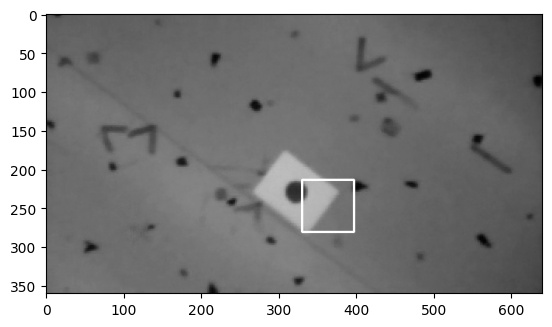

In [132]:
img_2696 = cv.imread(os.path.join(folder, "image_2696.jpg"), cv.IMREAD_GRAYSCALE)
best_y, best_x, best_r = best_parameters
w = 2*r + 1
top_left = (best_y, best_x)
bottom_right = (best_y + w, best_x + w)
cv.rectangle(img_2696,top_left, bottom_right, 255, 2)
plt.imshow(img_2696, cmap='gray')